In [ ]:
'''
Kind of a 'reduced' model, where the noise is added as a stochastic term, by computing approximate influences random values 
of x,y,and z have on T and S, and allowing for the drawing of additive and multiplicative noise terms from this calculation,
without the atmosphere. 
The drift terms are used for correction, the variances are used as noise amplitudes, and the noise term is drawn 
from A guassian distribution with the covariance of T and S caluclated.
Tsurf and Ssurf are statistically averaged out and replaced with their net effect, the drift terms cT and cS-> I think I still 
need to keep theta0, theta1 and sigma0 and sigma1.
'''

In [34]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
rng = np.random.default_rng(123)

In [25]:
zeros = pd.read_csv('../data/SDE_terms.csv')

In [26]:
def smoothabs(x, xi=10000):
    """Smooth absolute value function"""
    return x * np.tanh(x * xi)

In [27]:
def get_inputs(t0):
    dt_slow=0.025
    # pull the numbers that correspond to the current initial condition t0
    row          = zeros.loc[zeros['t0'] == t0].iloc[0]
    sT, sS, rho  = row['sigma_T'], row['sigma_S'], row['corr_TS']
    
    # covariance per unit time
    C_rate = np.array([[sT**2,           rho * sT * sS],
                       [rho * sT * sS,   sS**2      ]])     # units: (variable)^2 / time
    
    #Convert to covariance for one slow step
    C_step = C_rate * dt_slow                                # units: (variable)^2
    
    # 3.  Draw one correlated Gaussian increment  ξ  ~  N(0, C_step)
    eigvals, eigvecs = np.linalg.eigh(C_step)                # repair if numeric noise
    eigvals_clipped  = np.clip(eigvals, 0.0, None)
    C_step_psd       = (eigvecs * eigvals_clipped) @ eigvecs.T
    L                = np.linalg.cholesky(C_step_psd + 1e-16*np.trace(C_step_psd)*np.eye(2))
    xi               = L @ rng.normal(size=2)                # [ξ_T, ξ_S]

    
    return xi
    

In [30]:
def gottwald_noice(t,state,t0,params):
    """Gottwald model functions without sea ice"""
    theta_1=0.0195
    sigma_1=0.00934
    mu = 7.5
    sigma_0 = 0.9
    theta_0 = 1.
    epsilon_a = 0.34
    dt_slow=0.025

    T, S = state

    row          = zeros.loc[zeros['t0'] == t0].iloc[0]
    x_avg_corr,delta_avg_corr  = row['x_avg_corr'], row['delta_avg_corr']
    
    #Delta = y**2 + z**2
    T_surf = theta_0 + theta_1 * x_avg_corr
    S_surf = sigma_0 + sigma_1 * delta_avg_corr

    dT_det = -1/epsilon_a*(T - T_surf) - T - mu*smoothabs(S - T)*T
    dS_det =  S_surf - S            - mu*smoothabs(S - T)*S

    #for i in range(10):
    xi=get_inputs(0)
    T += dT_det * dt_slow + xi[0]   # add correlated noise
    S += dS_det * dt_slow + xi[1]
    
    #dx = 1/epsilon_f*(-Delta - a*(x - F0 - F1*T))
    #dy = 1/epsilon_f*(x*y - b*x*z - (y - G0 + G1*T))
    #dz = 1/epsilon_f*(b*x*y + x*z - z)
    #dT = -1/epsilon_a*(T - T_surf) - T - mu*smoothabs(S-T)*T + np.random.uniform(0,1)*TS_corr*sigma_T
    #dS = S_surf - S - mu*smoothabs(S-T)*S + np.random.uniform(0,1)*TS_corr*sigma_S
    
    return np.array([T, S])

In [41]:
T0=0
S0=0
state0 = np.array([T0, S0])
solution=[]
solution.append(state0)
T_final = 1000.0     # final simulation time
dt_slow = 0.025    
t_eval = np.arange(0, T_final + dt_slow, dt_slow)

for t in t_eval[1:]:
    state = gottwald_noice(t, state=state0, t0=T0, params=None) 
    solution.append(state.copy())

sol = np.array(solution)  # shape: (len(t_eval), 2)

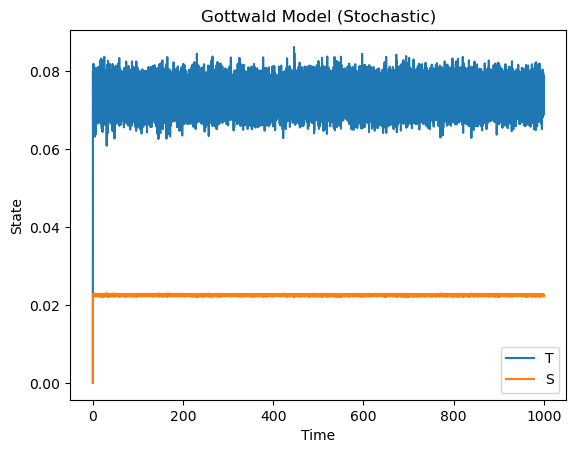

In [42]:
plt.plot(t_eval, sol[:, 0], label="T") 
plt.plot(t_eval, sol[:, 1], label="S") 
plt.xlabel("Time") 
plt.ylabel("State") 
plt.title("Gottwald Model (Stochastic)") 
plt.legend() 
plt.show()

In [45]:
#means of T and S, d model
print(sol[:,0].mean())
print(sol[:,1].mean())
#variance of S and T
print(sol[:,0].var())
print(sol[:,1].var())
#covariance
cov_TS = ((sol[:,0] - sol[:,0].mean()) * sol[:,1] - sol[:,1].mean()).mean() 
print(cov_TS)

0.07354962472058374
0.022498740999663848
8.41261981238821e-06
2.6324261715261562e-08
-0.02249903489922507


(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.1540e+03, 3.4566e+04, 3.2800e+03]),
 array([0.        , 0.00861679, 0.01723358, 0.02585037, 0.03446717,
        0.04308396, 0.05170075, 0.06031754, 0.06893433, 0.07755112,
        0.08616791]),
 <BarContainer object of 10 artists>)

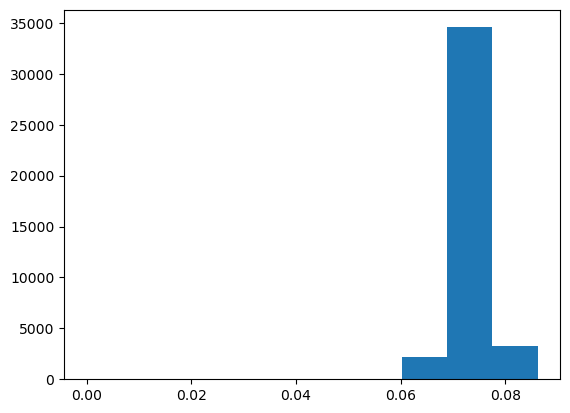

In [46]:
plt.hist(sol[:,0])

(array([1.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
        0.e+00, 4.e+04]),
 array([0.        , 0.00230295, 0.0046059 , 0.00690885, 0.0092118 ,
        0.01151475, 0.0138177 , 0.01612065, 0.0184236 , 0.02072655,
        0.0230295 ]),
 <BarContainer object of 10 artists>)

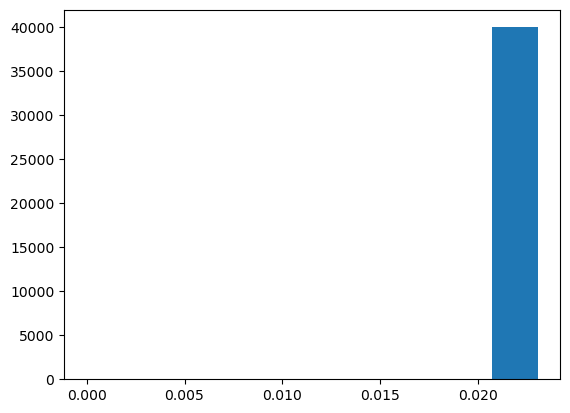

In [47]:
plt.hist(sol[:,1])

In [53]:
def autocorrelation(var):
    target_list = np.array(var)
    print(len(target_list))
    num_slices = 100
    slice_length = len(target_list) // num_slices
    
    #Split series into slices
    slices = np.array_split(target_list, num_slices)
    
    #Initialize array to store ACF for each slice
    expectations = np.zeros((num_slices, slice_length))
    
    for slice_num, s in enumerate(slices):
        s = np.array(s)
        mean_s = np.mean(s)
        var_s = np.var(s)
    
        #Compute autocovariance for each lag
        for lag in range(slice_length):
            #Take all overlapping pairs at this lag, s[:len(s)-lag] -> all except last values, (s[lag:]) -> all except first vals
            products = (s[:len(s)-lag] - mean_s) * (s[lag:] - mean_s)
            expectations[slice_num, lag] = np.mean(products) / var_s 
    
    #Average ACF across slices
    ACF = np.mean(expectations, axis=0)
    
    return ACF

40001


Text(0, 0.5, 'Auto-correlation')

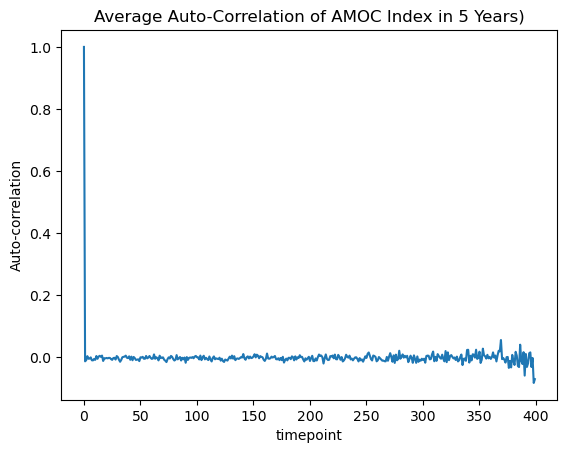

In [54]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_s = autocorrelation(sol[:,1])
plt.figure()
plt.plot(ACF_s)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')

40001


Text(0, 0.5, 'Auto-correlation')

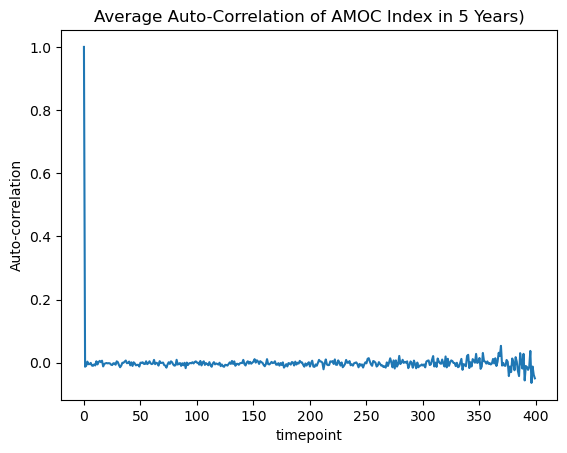

In [55]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_t = autocorrelation(sol[:,0])
plt.figure()
plt.plot(ACF_t)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')